In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

In [2]:
celegan_pca = pd.read_csv('/Users/lyuan13/Downloads/scPhere/out/celegan_pca.csv')
celegan_pca_ori = pd.read_csv('/Users/lyuan13/Downloads/scPhere/out/pca_celegan_ori.csv')
celegan_ll = pd.read_csv('/Users/lyuan13/Downloads/scPhere/out/celegan_latent_normal_10epoch_2572sec.tsv', sep=' ', header=None)
celegan_pca50 = pd.read_csv('/Users/lyuan13/Downloads/Celegan_combined_reductions_with_50PCs_and_times.csv')

In [3]:
def rotate_to_north_pole(points, centroid):
    # 
    norm_centroid = np.linalg.norm(centroid)
    if norm_centroid == 0:
        raise ValueError("Centroid has zero magnitude, cannot perform rotation.")
    north_pole = np.array([0, 0, 1])
    rotation_axis = np.cross(centroid, north_pole)
    rotation_angle = np.arccos(np.dot(centroid, north_pole) / norm_centroid)
    # 
    K = np.array([
        [0, -rotation_axis[2], rotation_axis[1]],
        [rotation_axis[2], 0, -rotation_axis[0]],
        [-rotation_axis[1], rotation_axis[0], 0]
    ])
    I = np.identity(3)
    R = I + np.sin(rotation_angle) * K + (1 - np.cos(rotation_angle)) * np.dot(K, K)
    #
    rotated_points = np.dot(points, R.T)
    return rotated_points
#
def convert_cluster_to_time(cluster):
    if '-' in cluster:
        start, end = cluster.split('-')
        return (int(start) + int(end)) / 2  # Average time
    elif '<' in cluster:
        return int(cluster.replace('< ', '')) - 1  # Slightly less than the specified time
    elif '>' in cluster:
        return int(cluster.replace('> ', '')) + 1  # Slightly more than the specified time
    return int(cluster) 
#
def calculate_distance_from_centroid(row, centroid):
    return np.sqrt(sum((row[dim] - centroid[dim])**2 for idx, dim in enumerate(centroid.keys())))
#
def cartesian_to_spherical(x, y, z):
    longitude = np.arctan2(y, x)
    latitude = np.arcsin(z / np.sqrt(x**2 + y**2 + z**2))
    return longitude, latitude
#
def calculate_2d_distance(row, centroid, prefix):
    return np.sqrt((row[f'{prefix}_lon'] - centroid['lon'])**2 + (row[f'{prefix}_lat'] - centroid['lat'])**2)

In [4]:
celegan_ll.columns = ['scPhere1','scPhere2','scPhere3']
data = pd.concat([celegan_pca, celegan_ll], axis=1)
#
data['time'] = data['cluster'].apply(convert_cluster_to_time) 

# Rotate the points so that the centroid of the 100-130 cluster is the north pole
filtered_data = celegan_pca.dropna(subset=['celltype'])
rotated_points = rotate_to_north_pole(data[['PC1','PC2','PC3']].values,  filtered_data[filtered_data['cluster'] == '100-130'][['PC1', 'PC2', 'PC3']].mean().values)

data['sphere_PC1'], data['sphere_PC2'], data['sphere_PC3'] = rotated_points.T
norms = np.linalg.norm(data[['sphere_PC1', 'sphere_PC2', 'sphere_PC3']], axis=1)
data['sphere_PC1'] = data['sphere_PC1'] / norms
data['sphere_PC2'] = data['sphere_PC2'] / norms
data['sphere_PC3'] = data['sphere_PC3'] / norms
#
data[['PC1', 'PC2', 'PC3']] = celegan_pca_ori[['PC1', 'PC2', 'PC3']].values

In [5]:
columns = {
    'tSNE1_3D': 'tSNE1',
    'tSNE2_3D': 'tSNE2',
    'tSNE3_3D': 'tSNE3',
    'tSNE1_2D': 'tSNE1_2D',
    'tSNE2_2D': 'tSNE2_2D',
    'UMAP1_3D': 'UMAP1',
    'UMAP2_3D': 'UMAP2',
    'UMAP3_3D': 'UMAP3',
    'UMAP1_2D': 'UMAP1_2D',
    'UMAP2_2D': 'UMAP2_2D'
}

#
tsne_umap = celegan_pca50[list(columns.keys())].rename(columns=columns)
data = pd.concat([data, tsne_umap], axis=1)

In [6]:
dimension_sets = {
    'PC': ['PC1', 'PC2', 'PC3'],
    'tSNE': ['tSNE1', 'tSNE2', 'tSNE3'],
    'tSNE_2D': ['tSNE1_2D', 'tSNE2_2D'],
    'UMAP': ['UMAP1', 'UMAP2', 'UMAP3'],
    'UMAP_2D': ['UMAP1_2D', 'UMAP2_2D'],
    'sphere_PC': ['sphere_PC1','sphere_PC2','sphere_PC3'],
    'scPhere':['scPhere1', 'scPhere2', 'scPhere3']
}

# --- PC ---
dims = dimension_sets['PC']
cluster_100_130 = data[data['cluster'] == '100-130']
centroid = {dims[i]: cluster_100_130[dims[i]].mean() for i in range(3)}
data['distance_to_centroid_PC'] = data.apply(
    lambda row: calculate_distance_from_centroid(row, centroid), axis=1
)

# --- tSNE ---
dims = dimension_sets['tSNE']
cluster_100_130 = data[data['cluster'] == '100-130']
centroid = {dims[i]: cluster_100_130[dims[i]].mean() for i in range(3)}
data['distance_to_centroid_tSNE'] = data.apply(
    lambda row: calculate_distance_from_centroid(row, centroid), axis=1
)

# --- tSNE 2D ---
dims = dimension_sets['tSNE_2D']
cluster_100_130 = data[data['cluster'] == '100-130']
centroid = {dims[i]: cluster_100_130[dims[i]].mean() for i in range(2)}
data['distance_to_centroid_tSNE_2D'] = data.apply(
    lambda row: calculate_distance_from_centroid(row, centroid), axis=1
)

# --- UMAP ---
dims = dimension_sets['UMAP']
cluster_100_130 = data[data['cluster'] == '100-130']
centroid = {dims[i]: cluster_100_130[dims[i]].mean() for i in range(3)}
data['distance_to_centroid_UMAP'] = data.apply(
    lambda row: calculate_distance_from_centroid(row, centroid), axis=1
)

# --- UMAP 2D ---
dims = dimension_sets['UMAP_2D']
cluster_100_130 = data[data['cluster'] == '100-130']
centroid = {dims[i]: cluster_100_130[dims[i]].mean() for i in range(2)}
data['distance_to_centroid_UMAP_2D'] = data.apply(
    lambda row: calculate_distance_from_centroid(row, centroid), axis=1
)

# --- sphere_PC ---
dims = dimension_sets['sphere_PC']
cluster_100_130 = data[data['cluster'] == '100-130']
centroid = {dims[i]: cluster_100_130[dims[i]].mean() for i in range(3)}
data['distance_to_centroid_sphere_PC'] = data.apply(
    lambda row: calculate_distance_from_centroid(row, centroid), axis=1
)

# --- scPhere ---
dims = dimension_sets['scPhere']
cluster_100_130 = data[data['cluster'] == '100-130']
centroid = {dims[i]: cluster_100_130[dims[i]].mean() for i in range(3)}
data['distance_to_centroid_scPhere'] = data.apply(
    lambda row: calculate_distance_from_centroid(row, centroid), axis=1
)


In [7]:
# --- sphere_PC & scPhere ---
for prefix in ['sphere_PC','scPhere']:
    data[f'{prefix}_lon'], data[f'{prefix}_lat'] = cartesian_to_spherical(
        data[f'{prefix}1'], data[f'{prefix}2'], data[f'{prefix}3']
    )

# Calculate centroid for `scPhere` and `sphere_PC`
centroids = {}
for prefix in ['scPhere','sphere_PC']:
    cluster_100_130 = data[data['cluster'] == '100-130']
    centroids[prefix] = {
        'lon': cluster_100_130[f'{prefix}_lon'].mean(),
        'lat': cluster_100_130[f'{prefix}_lat'].mean()
    }

# Calculate 2D distances to centroids
for prefix in ['scPhere', 'sphere_PC']:
    data[f'distance_to_centroid_{prefix}_2D'] = data.apply(
        lambda row: calculate_2d_distance(row, centroids[prefix], prefix), axis=1
    )

In [9]:
pearson_correlations = []
temporal_consistencies = []
local_temporal_variabilities = []

methods = ['scPhere', 'tSNE', 'UMAP', 'PC', 'sphere_PC']

# 
for prefix in methods:
    # Pearson Correlation
    if prefix == 'PC':
        pearson_correlation = data['time'].corr(data[f'distance_to_centroid_{prefix}'])
    else:
        pearson_correlation = data['time'].corr(data[f'distance_to_centroid_{prefix}_2D'])
    pearson_correlations.append(pearson_correlation)
    
    # Temporal Consistency
    sorted_indices = np.argsort(data['time'])
    sorted_distances = data[f'distance_to_centroid_{prefix}'].iloc[sorted_indices].reset_index(drop=True)
    temporal_consistency = np.mean(np.abs(sorted_distances.diff().dropna()))
    temporal_consistencies.append(temporal_consistency)
    
    # Local Temporal Variability
    local_temporal_variability = np.var(sorted_distances.diff().dropna())
    local_temporal_variabilities.append(local_temporal_variability)
    
print(pearson_correlations)
print(temporal_consistencies)
print(local_temporal_variabilities)

[0.7230905388731538, 0.6410366385328449, 0.5360519113693086, 0.5977326937893005, 0.7516470965340512]
[0.491214646784704, 8.840487320598896, 1.615201998153473, 6.413604885537242, 0.3427624926525604]
[0.4627842558160027, 128.731540489933, 5.031332610464241, 109.63495025175983, 0.22093824998749323]


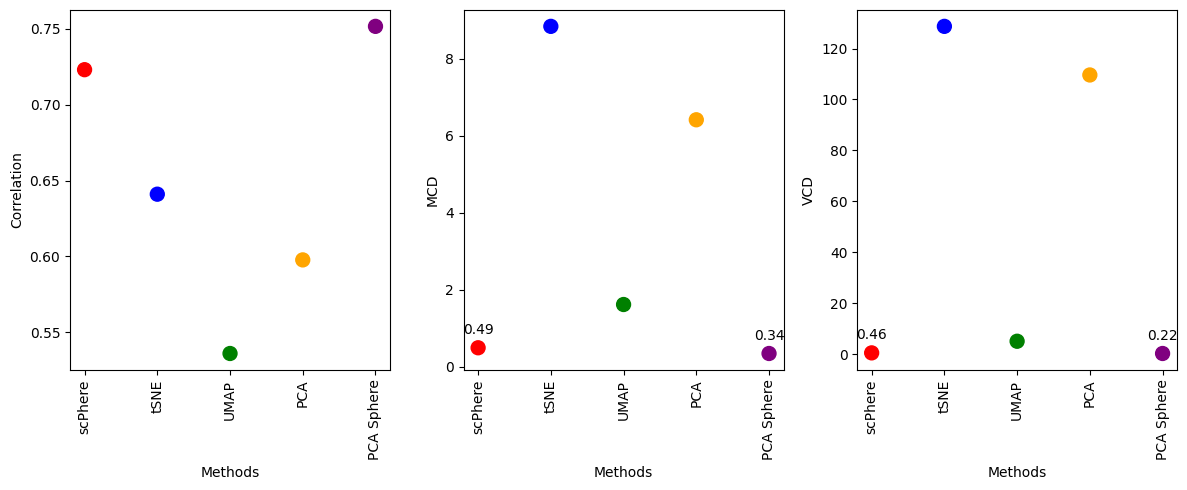

In [18]:
methods = ['scPhere', 'tSNE', 'UMAP', 'PCA', 'PCA Sphere']

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Plot Pearson Correlation with dots
axes[0].scatter(methods, pearson_correlations, color=['red', 'blue', 'green', 'orange', 'purple'], s=100)
#axes[0].set_title('Pearson Correlation')
axes[0].set_ylabel('Correlation')
axes[0].set_xlabel('Methods')
axes[0].tick_params(axis='x', rotation=90)

# Plot Temporal Consistency with dots
axes[1].scatter(methods, temporal_consistencies, color=['red', 'blue', 'green', 'orange', 'purple'], s=100)
#axes[1].set_title('Temporal Consistency')
axes[1].set_ylabel('MCD')
axes[1].set_xlabel('Methods')
axes[1].tick_params(axis='x', rotation=90)
for i, val in enumerate(temporal_consistencies):
    if methods[i] in ['scPhere', 'PCA Sphere']:
        axes[1].annotate(f"{val:.2f}", (methods[i], val), textcoords="offset points", xytext=(0, 10), ha='center')
        
# Plot Local Temporal Variability with dots
axes[2].scatter(methods, local_temporal_variabilities, color=['red', 'blue', 'green', 'orange', 'purple'], s=100)
#axes[2].set_title('Local Temporal Variability')
axes[2].set_ylabel('VCD')
axes[2].set_xlabel('Methods')
axes[2].tick_params(axis='x', rotation=90)
for i, val in enumerate(local_temporal_variabilities):
    if methods[i] in ['scPhere', 'PCA Sphere']:
        axes[2].annotate(f"{val:.2f}", (methods[i], val), textcoords="offset points", xytext=(0, 10), ha='center')

#
plt.tight_layout()
plt.show()